# Titanic Survival Analysis

This project explores the Titanic passenger dataset to understand the factors associated with passenger survival. The analysis covers data cleaning, feature engineering, exploratory data analysis, and basic statistical analysis.


## 1. Setup and Data Loading

First, I import the libraries I need and load the training and test datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.makedirs("images", exist_ok=True)


In [3]:
pd.set_option("display.max_columns", None)

In [4]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Initial Data Profiling

Before cleaning the data, I checked its size, columns, data types, missing values, duplicates, and basic statistics.

In [7]:
train.shape

(891, 12)

In [8]:
test.shape

(418, 11)

In [9]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Data Types

The dataset contains both numerical and text-based columns. Numerical columns include `Age`, `Fare`, `SibSp`, and `Parch`, while columns such as `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked` contain text or categorical information.

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [13]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
train.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


### Missing Values

There are missing values in `Age`, `Cabin`, and `Embarked`. `Cabin` has the most missing values, followed by `Age`, while only a small number of values are missing from `Embarked`.

In [15]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
missing_percentage = train.isnull().mean() * 100
missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [17]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Duplicate Records

I checked both datasets for complete duplicate rows.

In [18]:
train.duplicated().sum()

0

In [19]:
test.duplicated().sum()

0

### Basic Distributions

I checked a few main categorical variables and the `Survived` column to get a basic idea of the passengers in the training dataset.

In [20]:
train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [21]:
train["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [22]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [23]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [24]:
train["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

### Numerical Variables

The main numerical variables were reviewed to understand their ranges and basic statistics before cleaning.

In [25]:
train[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


## 3. Data Cleaning

I will now handle the missing values, check the data types, and check for duplicate rows. The choices are based on the profiling above.

In [26]:
df = train.copy()

### Handling Missing Age

`Age` has a number of missing values. I will use the median age to fill them because the median is less affected by unusually high or low ages than the mean.

In [27]:
df["Age"].median()

28.0

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [29]:
df["Age"].isnull().sum()

0

### Handling Missing Cabin Values

`Cabin` has a large number of missing values. Instead of making up cabin numbers, I will create a flag to show whether cabin information is available.

In [30]:
df["CabinKnown"] = df["Cabin"].notna().astype(int)

In [31]:
df["CabinKnown"].value_counts()

CabinKnown
0    687
1    204
Name: count, dtype: int64

`CabinKnown` uses `1` when cabin information is available and `0` when it is missing. The original `Cabin` column is kept for now because it may be useful later for feature engineering.

### Handling Missing Embarked Values

Only a small number of `Embarked` values are missing, so I will fill them with the most common value in the column.

In [32]:
df["Embarked"].mode()[0]

'S'

In [33]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [34]:
df["Embarked"].isnull().sum()

0

### Data Types

The data types were checked after cleaning. No unnecessary type conversions were made because the existing types are suitable for the analysis.

In [35]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
CabinKnown       int32
dtype: object

### Duplicate Records

The profiling step showed no complete duplicate rows, so there were no duplicate records to remove.

In [36]:
df.duplicated().sum()

0

### Final Missing Value Check

Finally, I checked the cleaned dataset to make sure the missing values that needed to be handled were addressed.

In [37]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
dtype: int64

## 4. Feature Engineering

I will create a few new columns from the existing data. These features will make it easier to compare passengers and look for patterns in survival.

### Passenger Title

The `Name` column contains a title for each passenger. I will extract the title and store it in a new `Title` column.

In [38]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

In [39]:
df[["Name", "Title"]].head()


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [40]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

### Family Size

`SibSp` shows the number of siblings or spouses travelling with a passenger, while `Parch` shows the number of parents or children. I will combine these with the passenger themselves to create a `FamilySize` column.

In [41]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [42]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [43]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

### IsAlone

I will create an `IsAlone` column to show whether a passenger was travelling without any family members.

In [44]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [45]:
df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [46]:
df[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


### New Features

The new features are checked below to make sure they were created correctly.

In [47]:
df[["Name", "Title", "SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,Name,Title,SibSp,Parch,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,1,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,0,2,0
2,"Heikkinen, Miss. Laina",Miss,0,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2,0
4,"Allen, Mr. William Henry",Mr,0,0,1,1
5,"Moran, Mr. James",Mr,0,0,1,1
6,"McCarthy, Mr. Timothy J",Mr,0,0,1,1
7,"Palsson, Master. Gosta Leonard",Master,3,1,5,0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,0,2,3,0
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,1,0,2,0


In [48]:
df[["Title", "FamilySize", "IsAlone"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       891 non-null    object
 1   FamilySize  891 non-null    int64 
 2   IsAlone     891 non-null    int32 
dtypes: int32(1), int64(1), object(1)
memory usage: 17.5+ KB


## 5. Exploratory Data Analysis

Now that the data has been cleaned and the new features have been created, I will explore the main variables and look for patterns related to passenger survival.

I will start with individual variables, check for possible outliers, then compare survival with a few important passenger characteristics.


### 5.1 Univariate Analysis

First, I will look at one variable at a time to understand the overall distribution of the data.


#### Age Distribution

The `Age` column shows the age of each passenger. I will use a histogram to see how the ages are distributed.


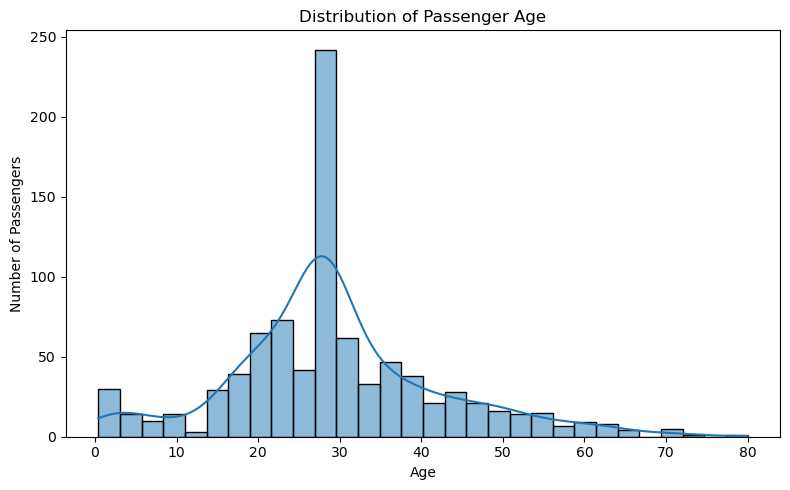

In [49]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("images/01_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Fare Distribution

Next, I will look at passenger fares. This helps show whether most passengers paid similar fares or if some fares were much higher than the rest.


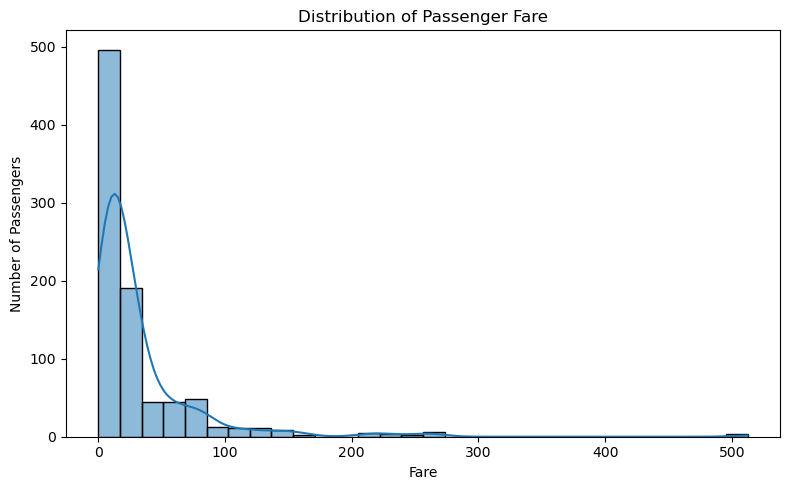

In [50]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("images/02_fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Passenger Class

`Pclass` represents the passenger class, where 1 is first class, 2 is second class, and 3 is third class.

I will look at how many passengers were in each class.


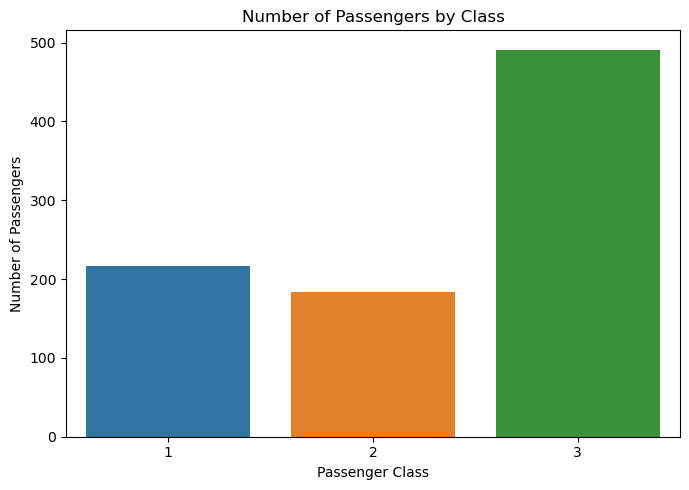

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass")

plt.title("Number of Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("images/03_passengers_by_class.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.2 Outlier Analysis

I will check `Age` and `Fare` for possible outliers using boxplots.

I will also use the IQR method to count the values that fall outside the usual range.


#### Age Outliers

The boxplot below shows the spread of passenger ages and any values that fall outside the main range.


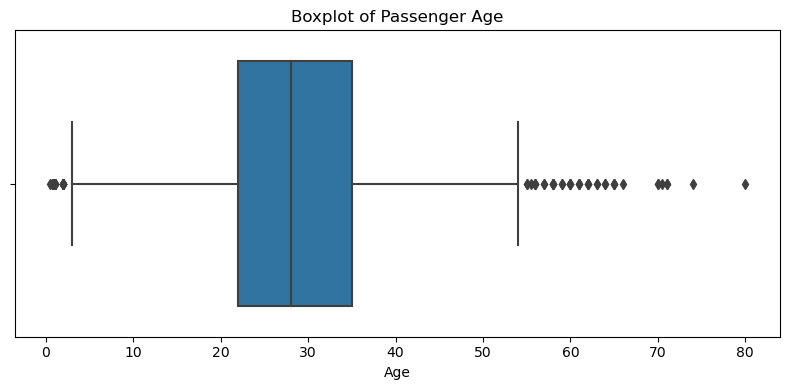

In [52]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Passenger Age")
plt.xlabel("Age")

plt.tight_layout()
plt.savefig("images/04_age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Fare Outliers

I will also check `Fare` because there is a large difference between the typical fare and the highest fares in the dataset.


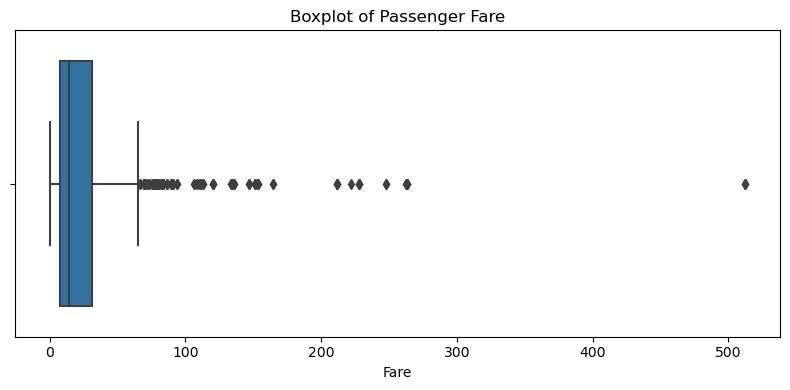

In [53]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")

plt.tight_layout()
plt.savefig("images/05_fare_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### IQR Outlier Check

The IQR is the difference between the 75th and 25th percentiles.

Values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are flagged as possible outliers.


In [54]:
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["Age"] < lower_age) | (df["Age"] > upper_age)
]

Q1_fare = df["Fare"].quantile(0.25)
Q3_fare = df["Fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["Fare"] < lower_fare) | (df["Fare"] > upper_fare)
]

outlier_summary = pd.DataFrame({
    "Variable": ["Age", "Fare"],
    "Outliers": [len(age_outliers), len(fare_outliers)]
})

outlier_summary


,Variable,Outliers
0,Age,66
1,Fare,116


The possible outliers were identified but not removed. These values may represent real passengers rather than data errors, so I will keep them for the analysis.


### 5.3 Bivariate Analysis

Next, I will look at the relationship between survival and a few important passenger characteristics.


#### Survival Rate by Sex

Sex is one of the main variables I want to compare with survival. I will calculate and plot the survival rate for male and female passengers.


In [55]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
survival_by_sex


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

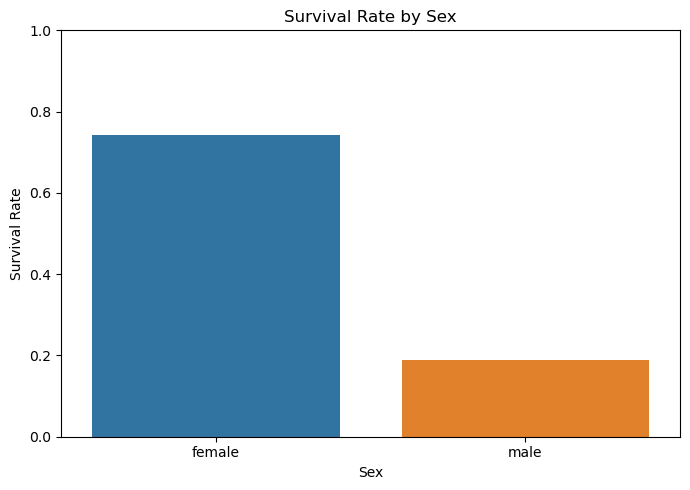

In [56]:
plt.figure(figsize=(7, 5))

sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("images/06_survival_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Survival Rate by Passenger Class

I will compare survival rates across the three passenger classes to see whether class was associated with survival.


In [57]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

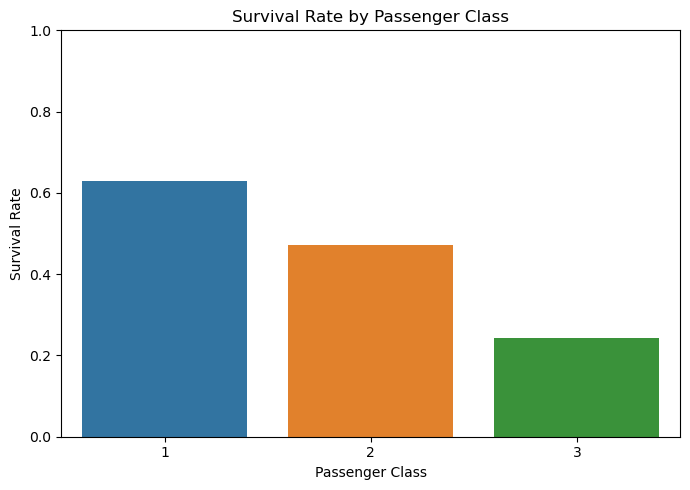

In [58]:
plt.figure(figsize=(7, 5))

sns.barplot(x=survival_by_class.index, y=survival_by_class.values)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("images/07_survival_by_class.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Survival Rate by Family Size

The `FamilySize` feature created earlier can now be used to see whether family size was related to survival.


In [59]:
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
survival_by_family


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

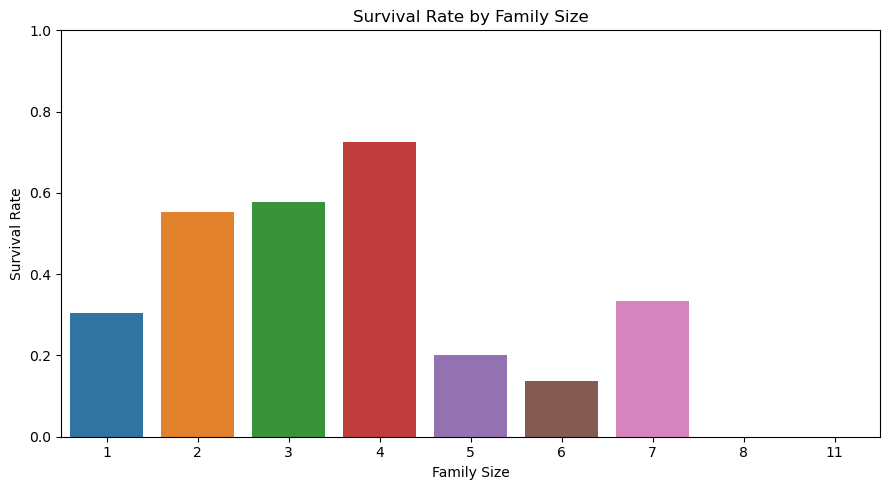

In [60]:
plt.figure(figsize=(9, 5))

sns.barplot(x=survival_by_family.index, y=survival_by_family.values)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("images/08_survival_by_family_size.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### 5.4 Multivariate Analysis

Finally, I will look at several variables together using a correlation heatmap.


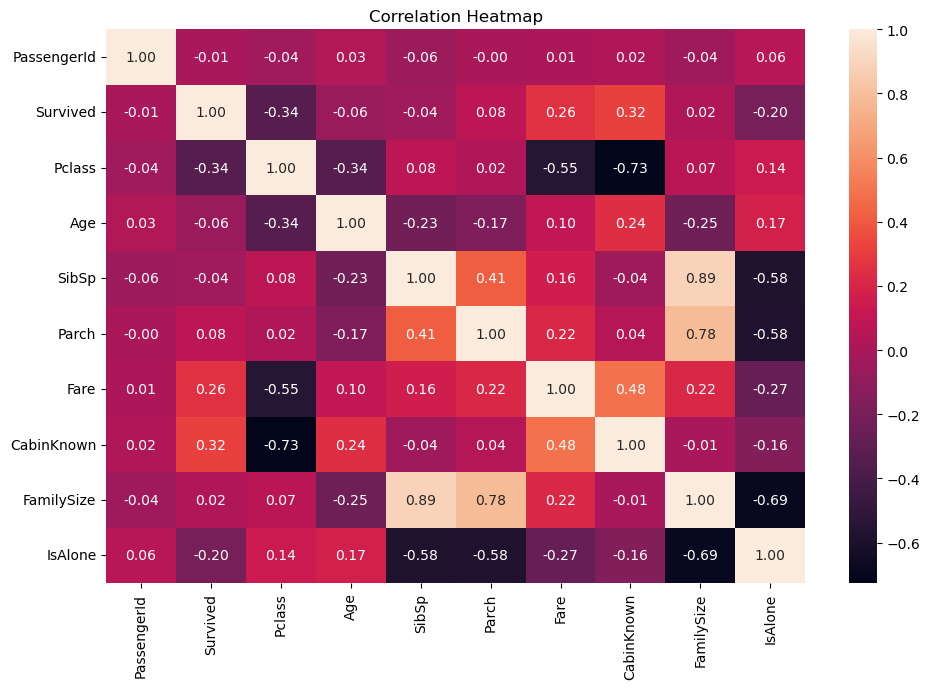

In [61]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("images/09_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


#### Survival by Sex and Class

I will compare survival rates by both sex and passenger class to see how these variables work together.


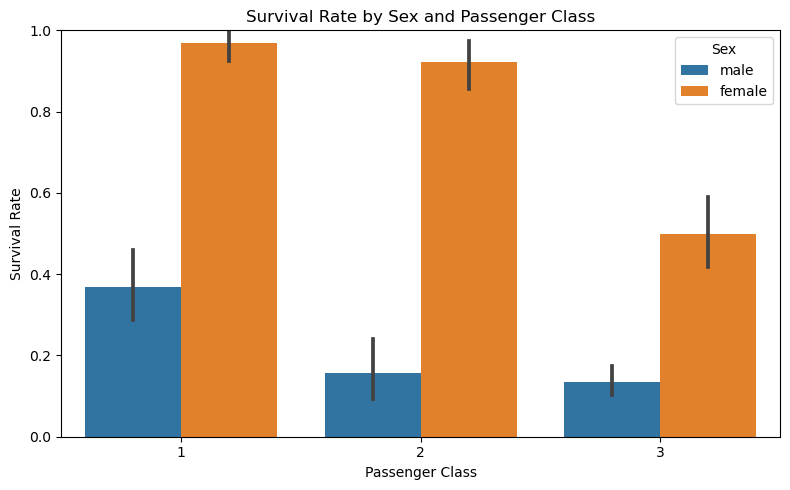

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("images/10_survival_by_sex_and_class.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


### Visualizations

The analysis above produces 10 visualizations. Each chart is also saved as a PNG file in the `images` folder so it can be used in the project README and GitHub repository.


## 6. Visualizations

The analysis includes several visualizations to make the main patterns in the data easier to understand.

The charts were created using Matplotlib and Seaborn and saved as PNG files in the `images` folder.


### Visualization Summary

The visualizations cover the main parts of the analysis, including passenger distributions, possible outliers, survival rates, and relationships between variables.


## 7. Basic Statistical Analysis

The visualizations show some patterns in the data, but I also want to support them with some basic statistics.

I will use summary statistics and group-by calculations to look at the data in more detail.

### 7.1 Summary Statistics

First, I will look at some basic statistics for the numerical variables.

In [63]:
df[["Age", "Fare", "SibSp", "Parch", "FamilySize"]].describe()

,Age,Fare,SibSp,Parch,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594,1.904602
std,13.019697,49.693429,1.102743,0.806057,1.613459
min,0.420000,0.000000,0.000000,0.000000,1.000000
25%,22.000000,7.910400,0.000000,0.000000,1.000000
50%,28.000000,14.454200,0.000000,0.000000,1.000000
75%,35.000000,31.000000,1.000000,0.000000,2.000000
max,80.000000,512.329200,8.000000,6.000000,11.000000


### 7.2 Overall Survival Rate

I will calculate the overall survival rate for the training dataset.

In [ ]:
overall_survival_rate = df["Survived"].mean()
overall_survival_rate

0.3838383838383838

In [65]:
print(f"Overall survival rate: {overall_survival_rate:.2%}")

Overall survival rate: 38.38%


### 7.3 Survival by Sex

I will compare the number of passengers and survival rate for each sex.

In [ ]:
survival_sex_stats = df.groupby("Sex").agg(
    Passengers=("Survived", "count"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)
survival_sex_stats

,Passengers,Survivors,Survival_Rate
Sex,,,
female,314,233,0.742038
male,577,109,0.188908


### 7.4 Survival by Passenger Class

Next, I will compare the number of passengers, survivors, and survival rate across the three passenger classes.

In [ ]:
survival_class_stats = df.groupby("Pclass").agg(
    Passengers=("Survived", "count"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)
survival_class_stats

,Passengers,Survivors,Survival_Rate
Pclass,,,
1,216,136,0.629630
2,184,87,0.472826
3,491,119,0.242363


### 7.5 Survival by Family Size

I will also look at survival rates across different family sizes.

In [ ]:
survival_family_stats = df.groupby("FamilySize").agg(
    Passengers=("Survived", "count"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)
survival_family_stats

,Passengers,Survivors,Survival_Rate
FamilySize,,,
1,537,163,0.303538
2,161,89,0.552795
3,102,59,0.578431
4,29,21,0.724138
5,15,3,0.200000
6,22,3,0.136364
7,12,4,0.333333
8,6,0,0.000000
11,7,0,0.000000


### 7.6 Correlation Analysis

Finally, I will look at the correlations between the main numerical variables.

Correlation shows how two variables move in relation to each other. It does not mean that one variable causes the other.

In [ ]:
correlation = df[
    ["Survived", "Age", "Fare", "Pclass", "SibSp", "Parch", "FamilySize", "IsAlone"]
].corr()
correlation

,Survived,Age,Fare,Pclass,SibSp,Parch,FamilySize,IsAlone
Survived,1.000000,-0.064910,0.257307,-0.338481,-0.035322,0.081629,0.016639,-0.203367
Age,-0.064910,1.000000,0.096688,-0.339898,-0.233296,-0.172482,-0.245619,0.171647
Fare,0.257307,0.096688,1.000000,-0.549500,0.159651,0.216225,0.217138,-0.271832
Pclass,-0.338481,-0.339898,-0.549500,1.000000,0.083081,0.018443,0.065997,0.135207
SibSp,-0.035322,-0.233296,0.159651,0.083081,1.000000,0.414838,0.890712,-0.584471
Parch,0.081629,-0.172482,0.216225,0.018443,0.414838,1.000000,0.783111,-0.583398
FamilySize,0.016639,-0.245619,0.217138,0.065997,0.890712,0.783111,1.000000,-0.690922
IsAlone,-0.203367,0.171647,-0.271832,0.135207,-0.584471,-0.583398,-0.690922,1.000000


### Correlation with Survival

I will sort the correlations with `Survived` to see which numerical variables have the strongest relationships with survival.

In [ ]:
survival_correlations = correlation["Survived"].sort_values(ascending=False)
survival_correlations

Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
IsAlone      -0.203367
Pclass       -0.338481
Name: Survived, dtype: float64

### Statistical Summary

The group-by tables show differences in survival rates across sex, passenger class, and family size.

The correlation analysis also gives a quick view of how the numerical variables are related to survival. These statistics will be used along with the visualizations when writing the final findings.